COURSE QUALITY DATASET

First 5 Records

  Course_ID       Course_Name Department        Module Lesson_Title  \
0     C1001   AI Fundamentals      AI&DS       Project     Lesson 5   
1     C1002  Java Programming      AI&DS        Basics    Lesson 17   
2     C1003              DBMS        CSE      Advanced    Lesson 24   
3     C1004  Java Programming      AI&DS  Intermediate     Lesson 5   
4     C1005              DBMS        ECE        Basics    Lesson 18   

   Content_Word_Count  Sentence_Count  Readability_Score  Grammar_Score  \
0                1804           210.0               81.1           45.8   
1                2488           263.0               66.3           91.8   
2                1000           136.0               37.7           48.6   
3                2103            56.0               58.2           42.7   
4                2999            40.0               65.2           93.9   

   Learning_Objective_Match  Student_Rating  Completion_Rate  Feedback_Count  \
0

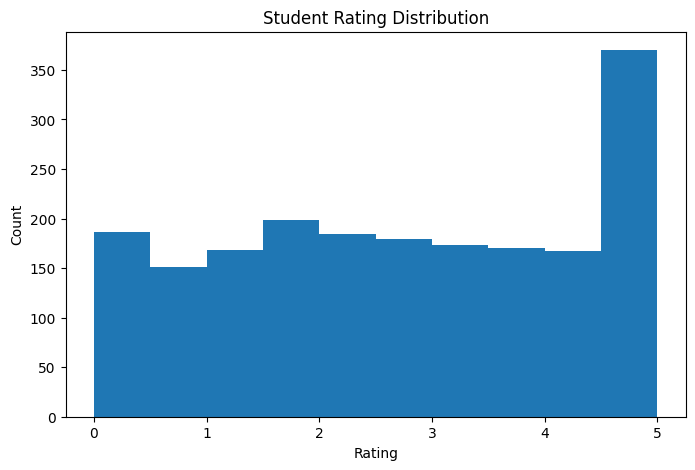

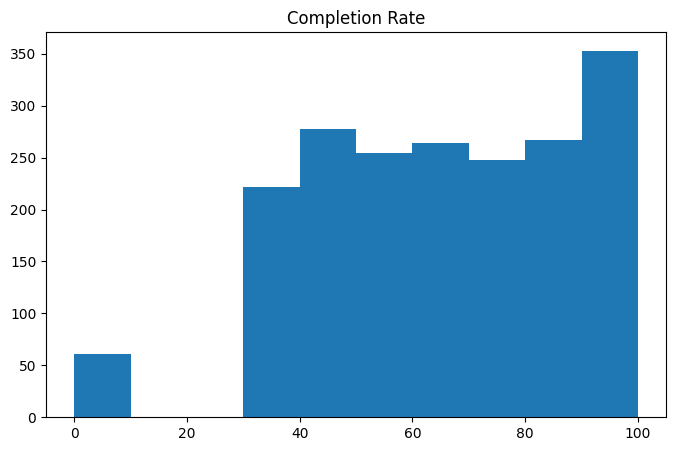

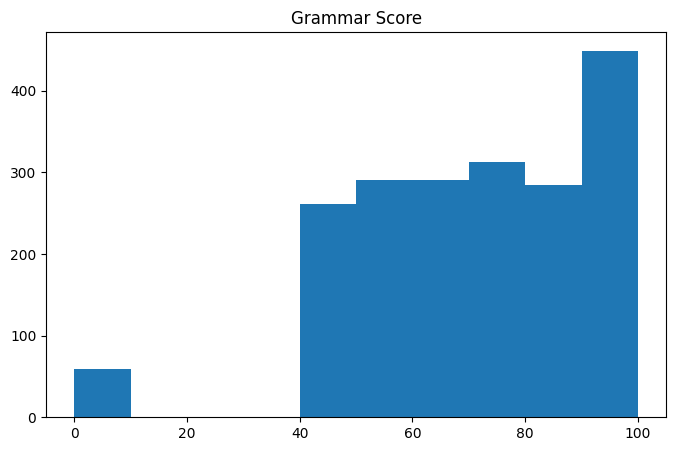

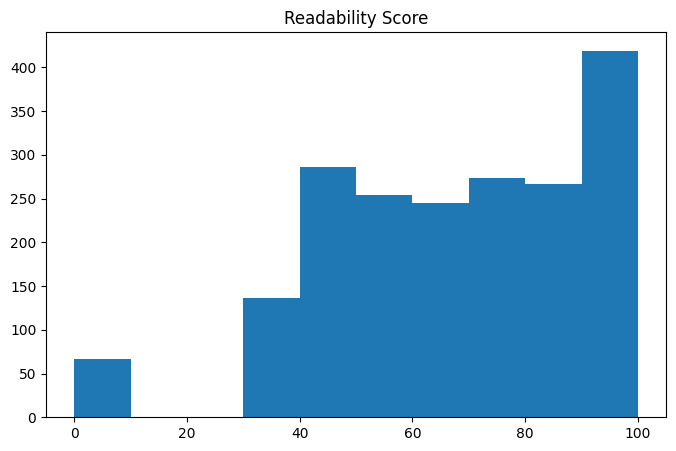

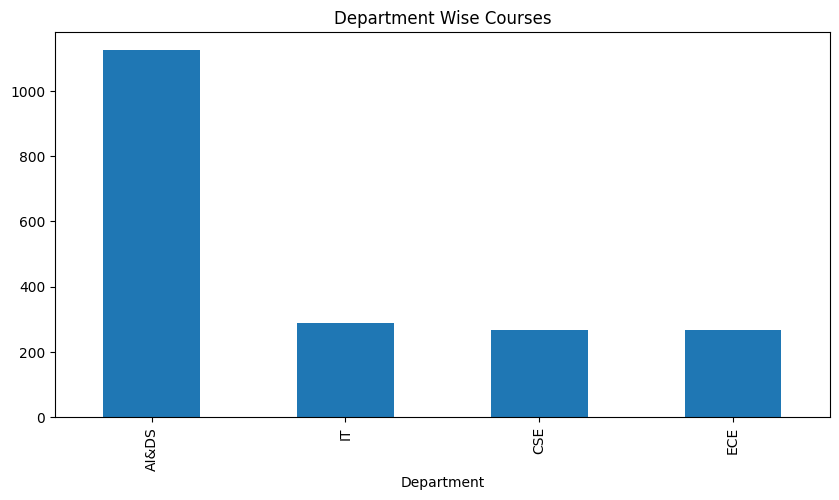

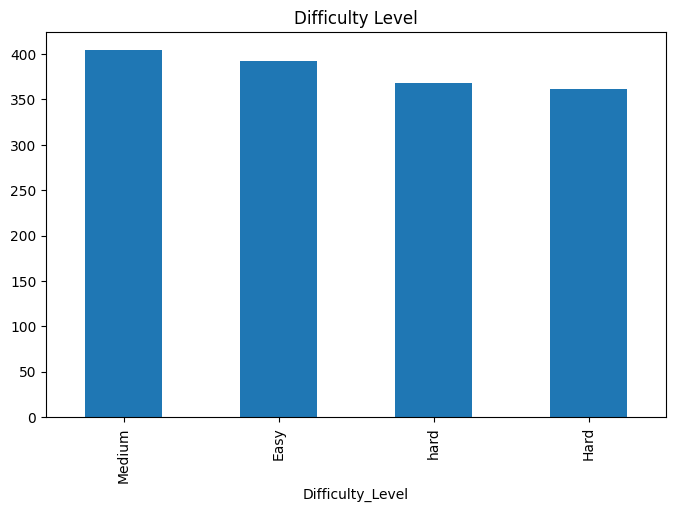

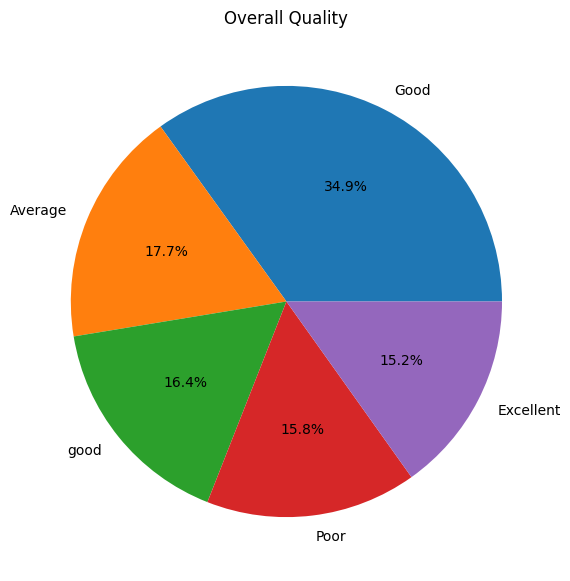

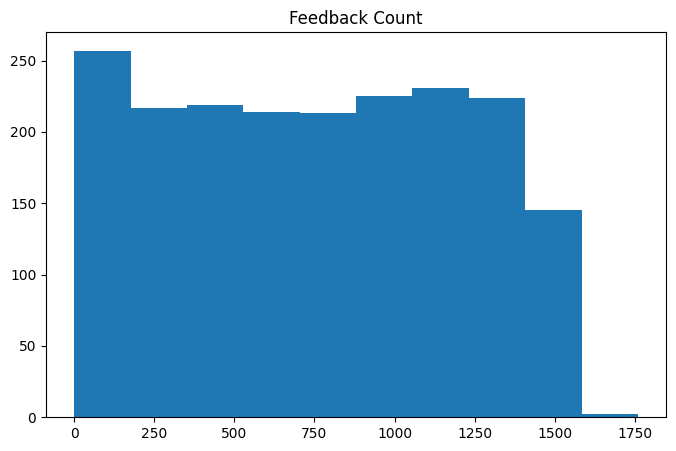

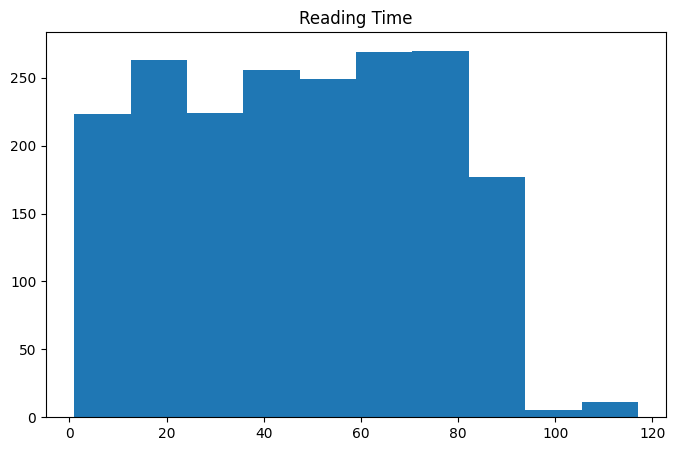

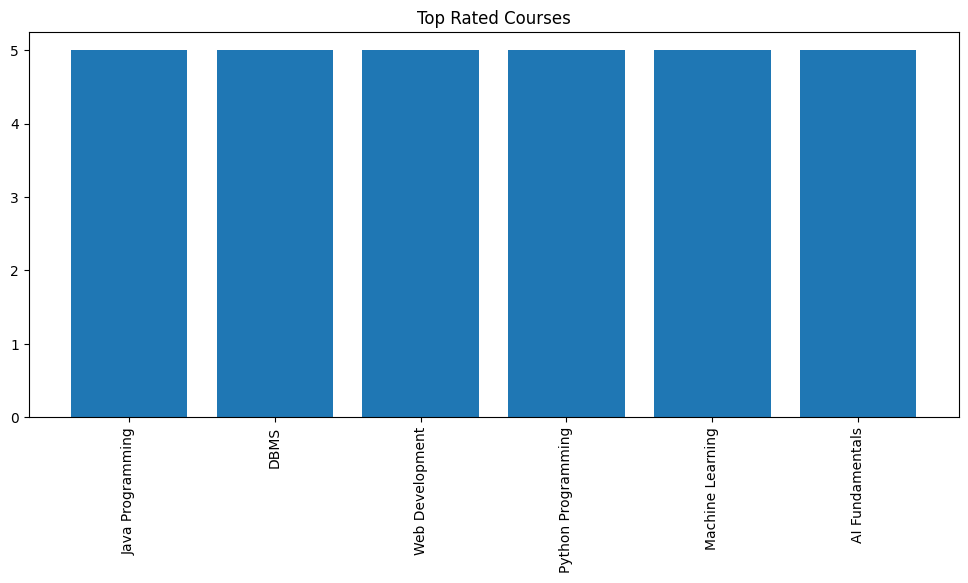

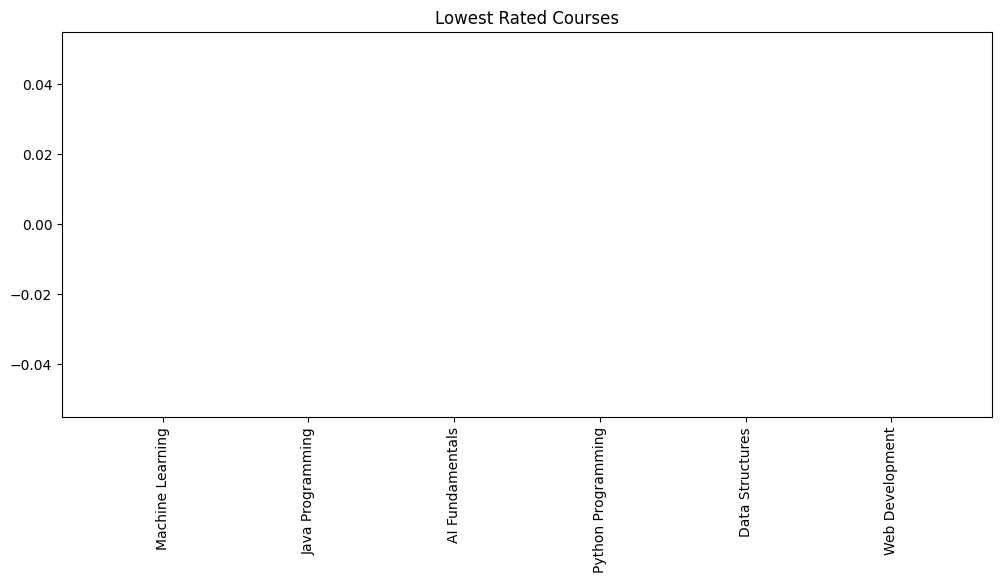

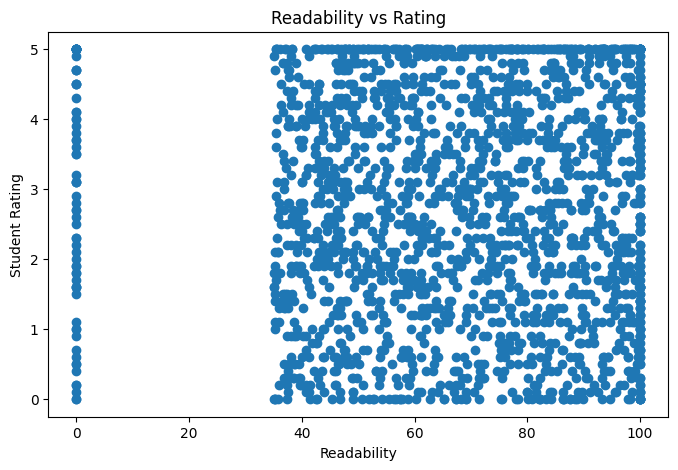

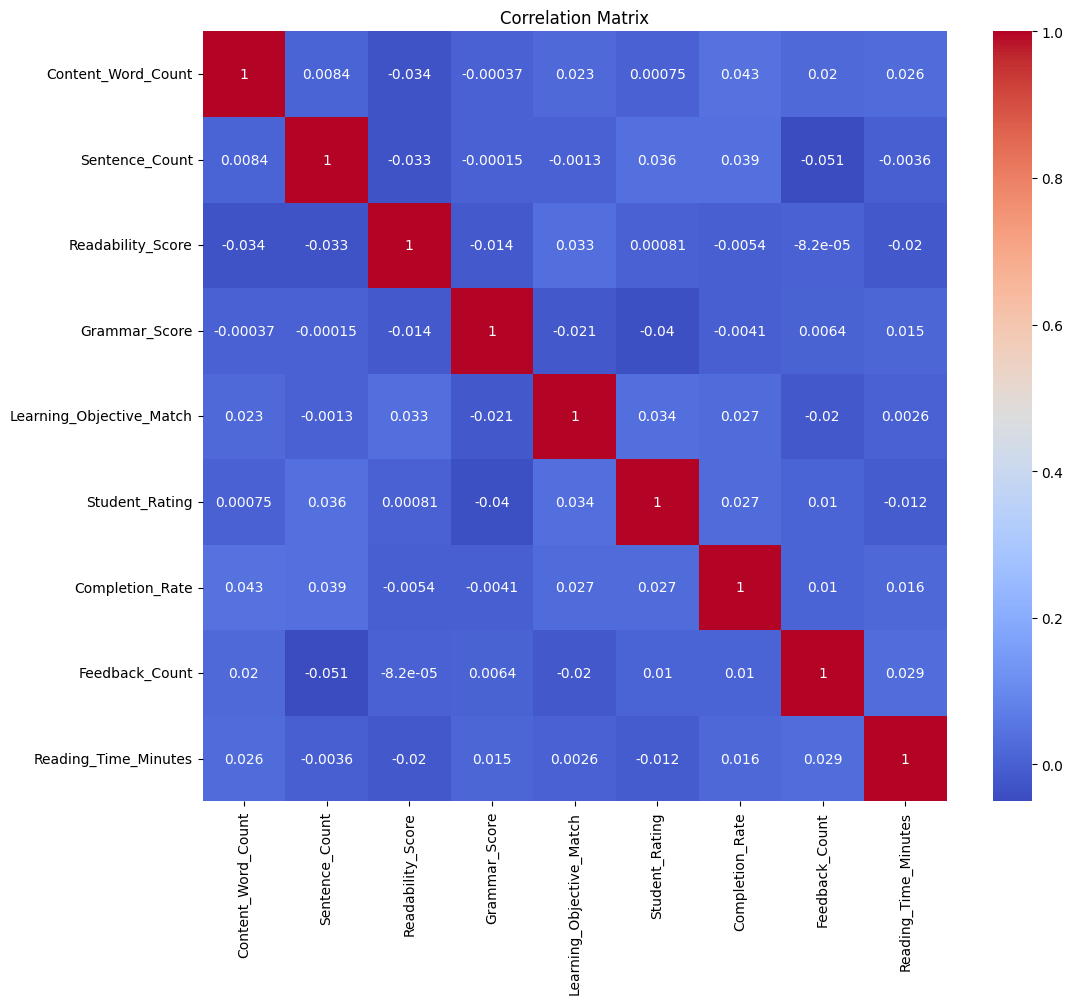

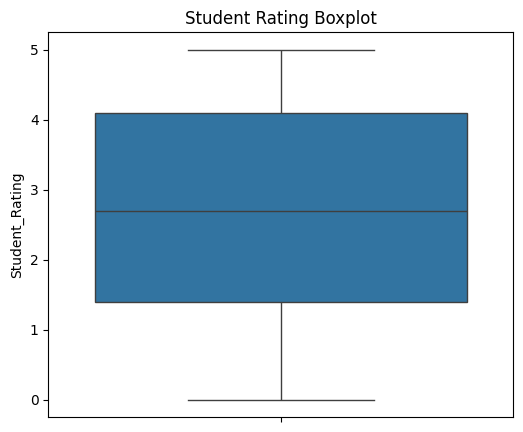

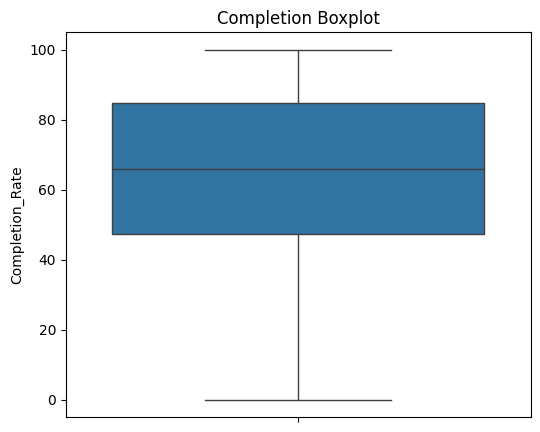

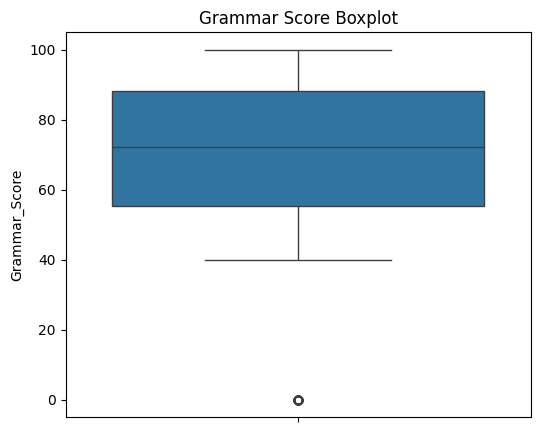



Analysis Completed Successfully
Graphs Saved Inside graphs Folder
Report Saved Inside reports Folder


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# Create Output Folders
# ----------------------------

os.makedirs("graphs", exist_ok=True)
os.makedirs("reports", exist_ok=True)

# ----------------------------
# Load Dataset
# ----------------------------

df = pd.read_csv("Master_Education_Cleaned.csv")

print("="*70)
print("COURSE QUALITY DATASET")
print("="*70)

# ----------------------------
# Basic Information
# ----------------------------

print("\nFirst 5 Records\n")
print(df.head())

print("\nShape")
print(df.shape)

print("\nColumns")
print(df.columns)

print("\nInformation")
print(df.info())

print("\nStatistics")
print(df.describe())

# ----------------------------
# Missing Values
# ----------------------------

print("\nMissing Values")

print(df.isnull().sum())

# ----------------------------
# Duplicate Values
# ----------------------------

print("\nDuplicate Rows")

print(df.duplicated().sum())

# ----------------------------
# Basic KPIs
# ----------------------------

print("\nAverage Rating :",round(df["Student_Rating"].mean(),2))

print("Highest Rating :",df["Student_Rating"].max())

print("Lowest Rating :",df["Student_Rating"].min())

print("Average Grammar :",round(df["Grammar_Score"].mean(),2))

print("Average Readability :",round(df["Readability_Score"].mean(),2))

print("Average Completion :",round(df["Completion_Rate"].mean(),2))

print("Total Feedback :",df["Feedback_Count"].sum())

# ----------------------------
# Rating Distribution
# ----------------------------

plt.figure(figsize=(8,5))

plt.hist(df["Student_Rating"],bins=10)

plt.title("Student Rating Distribution")

plt.xlabel("Rating")

plt.ylabel("Count")

plt.savefig("graphs/rating_distribution.png")

plt.show()

# ----------------------------
# Completion Distribution
# ----------------------------

plt.figure(figsize=(8,5))

plt.hist(df["Completion_Rate"],bins=10)

plt.title("Completion Rate")

plt.savefig("graphs/completion_distribution.png")

plt.show()

# ----------------------------
# Grammar Distribution
# ----------------------------

plt.figure(figsize=(8,5))

plt.hist(df["Grammar_Score"],bins=10)

plt.title("Grammar Score")

plt.savefig("graphs/grammar_distribution.png")

plt.show()

# ----------------------------
# Readability Distribution
# ----------------------------

plt.figure(figsize=(8,5))

plt.hist(df["Readability_Score"],bins=10)

plt.title("Readability Score")

plt.savefig("graphs/readability_distribution.png")

plt.show()

# ----------------------------
# Department Wise Courses
# ----------------------------

plt.figure(figsize=(10,5))

df["Department"].value_counts().plot(kind="bar")

plt.title("Department Wise Courses")

plt.savefig("graphs/department.png")

plt.show()

# ----------------------------
# Difficulty Level
# ----------------------------

plt.figure(figsize=(8,5))

df["Difficulty_Level"].value_counts().plot(kind="bar")

plt.title("Difficulty Level")

plt.savefig("graphs/difficulty.png")

plt.show()

# ----------------------------
# Overall Quality
# ----------------------------

plt.figure(figsize=(7,7))

df["Overall_Quality"].value_counts().plot(
kind="pie",
autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Overall Quality")

plt.savefig("graphs/overall_quality.png")

plt.show()

# ----------------------------
# Feedback Distribution
# ----------------------------

plt.figure(figsize=(8,5))

plt.hist(df["Feedback_Count"])

plt.title("Feedback Count")

plt.savefig("graphs/feedback.png")

plt.show()

# ----------------------------
# Reading Time
# ----------------------------

plt.figure(figsize=(8,5))

plt.hist(df["Reading_Time_Minutes"])

plt.title("Reading Time")

plt.savefig("graphs/reading_time.png")

plt.show()

# ----------------------------
# Top Rated Courses
# ----------------------------

top=df.sort_values("Student_Rating",ascending=False).head(10)

plt.figure(figsize=(12,5))

plt.bar(top["Course_Name"],top["Student_Rating"])

plt.xticks(rotation=90)

plt.title("Top Rated Courses")

plt.savefig("graphs/top_courses.png")

plt.show()

# ----------------------------
# Lowest Rated Courses
# ----------------------------

low=df.sort_values("Student_Rating").head(10)

plt.figure(figsize=(12,5))

plt.bar(low["Course_Name"],low["Student_Rating"])

plt.xticks(rotation=90)

plt.title("Lowest Rated Courses")

plt.savefig("graphs/lowest_courses.png")

plt.show()

# ----------------------------
# Scatter Plot
# ----------------------------

plt.figure(figsize=(8,5))

plt.scatter(
df["Readability_Score"],
df["Student_Rating"]
)

plt.xlabel("Readability")

plt.ylabel("Student Rating")

plt.title("Readability vs Rating")

plt.savefig("graphs/readability_vs_rating.png")

plt.show()

# ----------------------------
# Correlation Matrix
# ----------------------------

numeric=df.select_dtypes(include=np.number)

corr=numeric.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
corr,
annot=True,
cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.savefig("graphs/correlation.png")

plt.show()

# ----------------------------
# Boxplots
# ----------------------------

plt.figure(figsize=(6,5))
sns.boxplot(y=df["Student_Rating"])
plt.title("Student Rating Boxplot")
plt.savefig("graphs/box_rating.png")
plt.show()

plt.figure(figsize=(6,5))
sns.boxplot(y=df["Completion_Rate"])
plt.title("Completion Boxplot")
plt.savefig("graphs/box_completion.png")
plt.show()

plt.figure(figsize=(6,5))
sns.boxplot(y=df["Grammar_Score"])
plt.title("Grammar Score Boxplot")
plt.savefig("graphs/box_grammar.png")
plt.show()

# ----------------------------
# Business Insights
# ----------------------------

report=[]

report.append("COURSE QUALITY ANALYSIS\n")
report.append("="*50)

report.append(f"\nTotal Courses : {len(df)}")
report.append(f"\nAverage Rating : {round(df['Student_Rating'].mean(),2)}")
report.append(f"\nAverage Completion : {round(df['Completion_Rate'].mean(),2)}")
report.append(f"\nAverage Grammar : {round(df['Grammar_Score'].mean(),2)}")
report.append(f"\nAverage Readability : {round(df['Readability_Score'].mean(),2)}")

report.append("\n\nBest Department\n")
report.append(str(
df.groupby("Department")["Student_Rating"]
.mean()
.sort_values(ascending=False)
.head()
))

report.append("\n\nTop Authors\n")
report.append(str(
df.groupby("Author")["Student_Rating"]
.mean()
.sort_values(ascending=False)
.head()
))

with open("reports/insights.txt","w") as f:
    f.write("\n".join(report))

print("\n\nAnalysis Completed Successfully")
print("Graphs Saved Inside graphs Folder")
print("Report Saved Inside reports Folder")